In [1]:

# Clone repo (for Google Colab – safe to re-run; no duplicate clone)
import os
REPO_DIR = "/content/High-Performance-Reduction-Kernels/reductions/sum"  # Colab starts in /content
os.chdir("/content")
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/sriharshapy/High-Performance-Reduction-Kernels.git
%cd /content/High-Performance-Reduction-Kernels/reductions/sum

Cloning into 'High-Performance-Reduction-Kernels'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 48 (delta 21), reused 41 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 801.07 KiB | 1.12 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/High-Performance-Reduction-Kernels/reductions/sum


In [2]:
!python input_gen_1D.py out.bin -n 1000000000   --seed 42

Wrote 1000000000 float32 values in [-1, 1] to out.bin


In [3]:
!nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d '.'

75


# Compiling hand written reduction and the Nvidia CUB

In [4]:
!nvcc -O3 \
  -arch=sm_$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d '.') \
  -use_fast_math \
  -Xptxas -O3,-v \
  --dlink-time-opt \
  -lineinfo \
  -o vector_sum_reduction vector_sum_reduction.cu

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_ZN3cub17CUB_200700_750_NS18DeviceReduceKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfyS7_fNS5_10__identityEEEvT0_PT3_T1_NS0_13GridEvenShareISF_EET2_T4_' for 'sm_75'
ptxas info    : Function properties for _ZN3cub17CUB_200700_750_NS18DeviceReduceKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfyS7_fNS5_10__identityEEEvT0_PT3_T1_NS0_13GridEvenShareISF_EET2_T4_
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 64 registers, used 1 barriers, 44 bytes smem, 450 bytes cmem[0]
ptxas info    : Compile time = 115.692 ms
ptxas info    : Compiling entry function '_ZN3cub17CUB_200700_750_NS28DeviceReduceSingleTileKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfSA_yS7_ffNS5_10__identityEEEvT0_T1_T2_T3_T4_T6_' for 'sm_75'
ptxas info    : Function properties for _ZN3cub17CUB_200700_750_NS28DeviceReduceSingleTileKernelINS0_1

In [5]:
!nvcc -O3 \
  -arch=sm_$(nvidia-smi --query-gpu=compute_cap --format=csv,noheader | head -1 | tr -d '.') \
  -use_fast_math \
  -Xptxas -O3,-v \
  --dlink-time-opt \
  -lineinfo \
  -o vector_sum_reduction_cub vector_sum_reduction_cub.cu

ptxas info    : 0 bytes gmem
ptxas info    : Compiling entry function '_ZN3cub17CUB_200700_750_NS18DeviceReduceKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfyS7_fNS5_10__identityEEEvT0_PT3_T1_NS0_13GridEvenShareISF_EET2_T4_' for 'sm_75'
ptxas info    : Function properties for _ZN3cub17CUB_200700_750_NS18DeviceReduceKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfyS7_fNS5_10__identityEEEvT0_PT3_T1_NS0_13GridEvenShareISF_EET2_T4_
    0 bytes stack frame, 0 bytes spill stores, 0 bytes spill loads
ptxas info    : Used 64 registers, used 1 barriers, 44 bytes smem, 450 bytes cmem[0]
ptxas info    : Compile time = 56.856 ms
ptxas info    : Compiling entry function '_ZN3cub17CUB_200700_750_NS28DeviceReduceSingleTileKernelINS0_18DeviceReducePolicyIfyN4cuda3std3__44plusIvEEE9Policy600EPfSA_yS7_ffNS5_10__identityEEEvT0_T1_T2_T3_T4_T6_' for 'sm_75'
ptxas info    : Function properties for _ZN3cub17CUB_200700_750_NS28DeviceReduceSingleTileKernelINS0_18

In [6]:
import subprocess
import re
import csv
import os

# Configuration
OUTPUT_BIN = "out.bin"
N_VALUES = [
    10_000,100_000, 500_000,1_000_000, 10_000_000, 50_000_000,
    100_000_000, 250_000_000, 500_000_000, 750_000_000, 1_000_000_000
]

SCRIPTS = [
    {"name": "PyTorch", "cmd": lambda n: ["python", "vector_sum_reduction_torch.py", OUTPUT_BIN, str(n)]},
    {"name": "Triton",       "cmd": lambda n: ["python", "vector_sum_reduction.py", OUTPUT_BIN, str(n)]},
    {"name": "CUDA CUB",      "cmd": lambda n: ["./vector_sum_reduction_cub", OUTPUT_BIN, str(n)]},
    {"name": "CUDA C",          "cmd": lambda n: ["./vector_sum_reduction", OUTPUT_BIN, str(n)]},
]

def parse_output(output):
    """Extract n and avg_kernel_ms from command output."""
    metrics = {}
    patterns = {
        "n":             r"n\s*=\s*(\d+)",
        "avg_kernel_ms": r"avg_kernel_ms\s*=\s*([\d.]+)",
        "sum":           r"sum\s*=\s*(-?[\d.]+)",
        "niterations":   r"niterations\s*=\s*(\d+)",
        "verify":        r"VERIFY\s+(PASS|FAIL)",
        "err":           r"err\s*=\s*([\d.e+-]+)",
        "tol":           r"tol\s*=\s*([\d.e+-]+)",
    }
    for key, pattern in patterns.items():
        m = re.search(pattern, output)
        if m:
            metrics[key] = m.group(1)
    return metrics

def run_command(cmd, n):
    """Run a command and return its stdout+stderr as a string."""
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=300
        )
        combined = result.stdout + result.stderr
        if result.returncode != 0:
            print(f"  [WARN] Non-zero exit code {result.returncode} for n={n}")
            print(f"  stderr: {result.stderr.strip()[:200]}")
        return combined
    except subprocess.TimeoutExpired:
        print(f"  [ERROR] Timeout for n={n}")
        return ""
    except FileNotFoundError as e:
        print(f"  [ERROR] Command not found: {e}")
        return ""

def main():
    csv_file = "benchmark_results.csv"
    fieldnames = ["file_name", "n", "avg_kernel_ms", "sum", "niterations", "verify", "err", "tol"]

    with open(csv_file, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for n in N_VALUES:
            print(f"\n{'='*50}")
            print(f"Running with n = {n:,}")
            print(f"{'='*50}")

            for script in SCRIPTS:
                name = script["name"]
                cmd  = script["cmd"](n)
                print(f"  Running: {' '.join(cmd)}")

                output = run_command(cmd, n)
                metrics = parse_output(output)

                row = {
                    "file_name":     name,
                    "n":             metrics.get("n", n),
                    "avg_kernel_ms": metrics.get("avg_kernel_ms", ""),
                    "sum":           metrics.get("sum", ""),
                    "verify":        metrics.get("verify", ""),
                    "niterations":   metrics.get("niterations", ""),
                    "tol":           metrics.get("tol", ""),
                }
                writer.writerow(row)
                f.flush()  # write incrementally so partial results are saved

                print(f"    -> n={row['n']}, avg_kernel_ms={row['avg_kernel_ms']}, sum={row['sum']}, niterations={row['niterations']}, verify={row['verify']}, tol={row['tol']}")

    print(f"\nDone! Results saved to '{csv_file}'")

if __name__ == "__main__":
    main()


Running with n = 10,000
  Running: python vector_sum_reduction_torch.py out.bin 10000
    -> n=10000, avg_kernel_ms=0.0300, sum=-57.56805038, niterations=100, verify=PASS, tol=0.058568
  Running: python vector_sum_reduction.py out.bin 10000
    -> n=10000, avg_kernel_ms=0.0749, sum=-57.5680542, niterations=100, verify=PASS, tol=0.058568
  Running: ./vector_sum_reduction_cub out.bin 10000
    -> n=10000, avg_kernel_ms=0.0112, sum=-57.56803894, niterations=100, verify=PASS, tol=0.0585681
  Running: ./vector_sum_reduction out.bin 10000
    -> n=10000, avg_kernel_ms=0.0084, sum=-57.56804657, niterations=100, verify=PASS, tol=0.0585681

Running with n = 100,000
  Running: python vector_sum_reduction_torch.py out.bin 100000
    -> n=100000, avg_kernel_ms=0.0323, sum=124.9873047, niterations=100, verify=PASS, tol=0.125987
  Running: python vector_sum_reduction.py out.bin 100000
    -> n=100000, avg_kernel_ms=0.0505, sum=124.9873505, niterations=100, verify=PASS, tol=0.125987
  Running: ./vec

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

CSV_FILE = "benchmark_results.csv"
OUT_DIR  = "analysis_output"
os.makedirs(OUT_DIR, exist_ok=True)

In [8]:
df = pd.read_csv(CSV_FILE)
df.columns = df.columns.str.strip()
df["n"]             = pd.to_numeric(df["n"],             errors="coerce")
df["avg_kernel_ms"] = pd.to_numeric(df["avg_kernel_ms"], errors="coerce")
df["sum"]           = pd.to_numeric(df["sum"],           errors="coerce")
df["err"]           = pd.to_numeric(df["err"],           errors="coerce")
df["tol"]           = pd.to_numeric(df["tol"],           errors="coerce")
df["niterations"]   = pd.to_numeric(df["niterations"],   errors="coerce")

scripts = df["file_name"].unique()
COLORS  = plt.cm.tab10.colors

def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {path}")

In [9]:
print("\n" + "═"*60)
print("1. STATISTICAL SUMMARY (avg_kernel_ms per script)")
print("═"*60)
summary = (
    df.groupby("file_name")["avg_kernel_ms"]
    .agg(count="count", mean="mean", std="std", min="min", median="median", max="max")
    .round(4)
)
print(summary.to_string())

print("\nVerify Pass Rate per script:")
if "verify" in df.columns:
    vr = df.groupby("file_name")["verify"].apply(
        lambda x: f"{(x.str.strip().str.upper() == 'PASS').sum()}/{len(x)} PASS"
    )
    print(vr.to_string())



════════════════════════════════════════════════════════════
1. STATISTICAL SUMMARY (avg_kernel_ms per script)
════════════════════════════════════════════════════════════
           count    mean     std     min  median      max
file_name                                                
CUDA C        11  3.5902  5.2230  0.0084  0.7419  14.8130
CUDA CUB      11  3.5934  5.2220  0.0112  0.7508  14.8102
PyTorch       11  3.5301  5.0991  0.0300  0.7582  14.4752
Triton        11  3.5733  5.1173  0.0505  0.7856  14.5267

Verify Pass Rate per script:
file_name
CUDA C      11/11 PASS
CUDA CUB    11/11 PASS
PyTorch     11/11 PASS
Triton      11/11 PASS



════════════════════════════════════════════════════════════
2. Performance Scaling Plot (log-log)
════════════════════════════════════════════════════════════


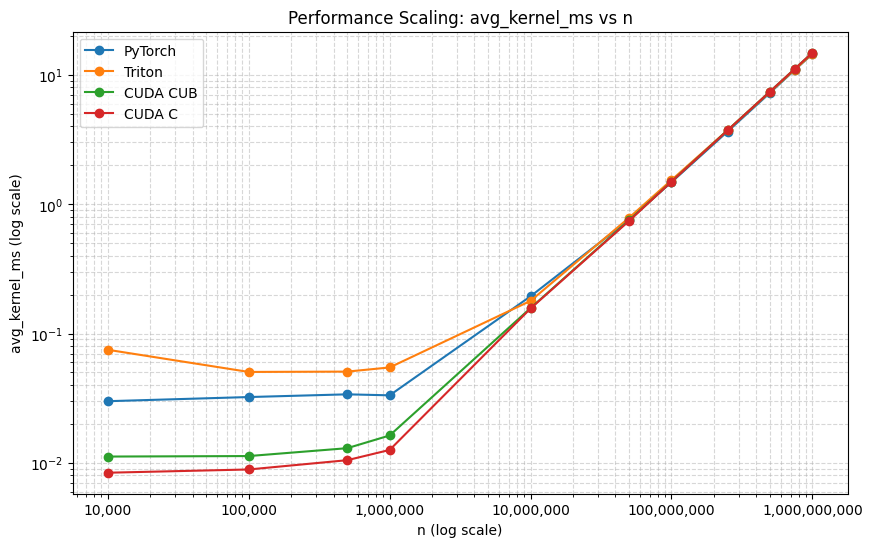

  Saved → analysis_output/1_performance_scaling.png


In [10]:
print("\n" + "═"*60)
print("2. Performance Scaling Plot (log-log)")
print("═"*60)
fig, ax = plt.subplots(figsize=(10, 6))
for i, script in enumerate(scripts):
    sub = df[df["file_name"] == script].dropna(subset=["n", "avg_kernel_ms"]).sort_values("n")
    ax.plot(sub["n"], sub["avg_kernel_ms"], marker="o", label=script, color=COLORS[i % len(COLORS)])

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("n (log scale)")
ax.set_ylabel("avg_kernel_ms (log scale)")
ax.set_title("Performance Scaling: avg_kernel_ms vs n")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
savefig("1_performance_scaling.png")



════════════════════════════════════════════════════════════
3. Cross-Script Comparison Bar Chart
════════════════════════════════════════════════════════════


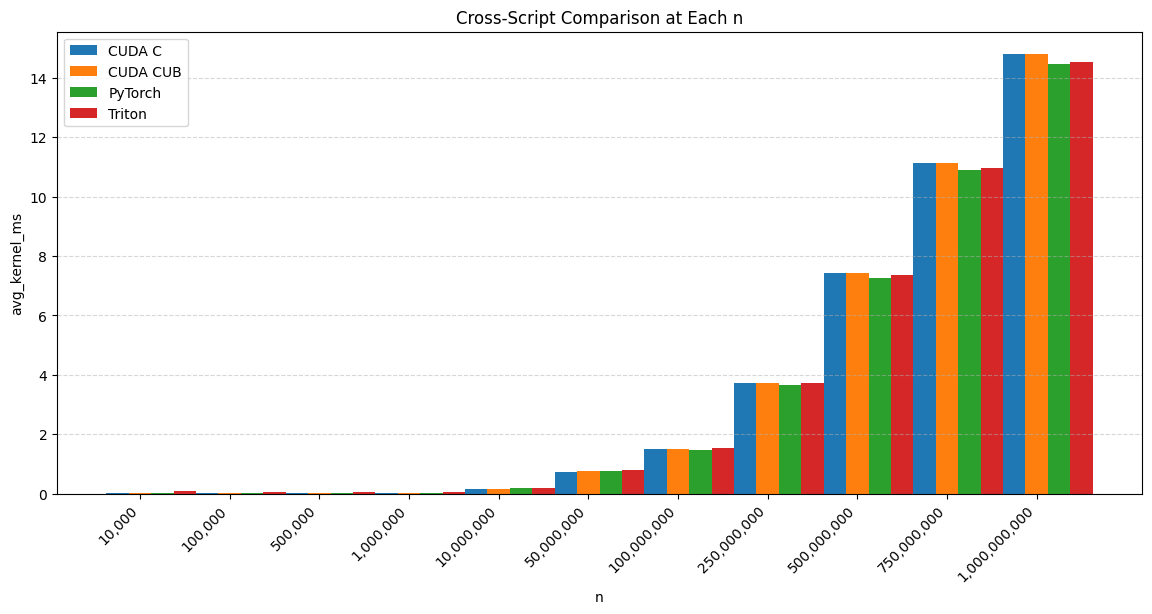

  Saved → analysis_output/2_cross_script_comparison.png


In [11]:
print("\n" + "═"*60)
print("3. Cross-Script Comparison Bar Chart")
print("═"*60)
pivot = df.pivot_table(index="n", columns="file_name", values="avg_kernel_ms")
pivot = pivot.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
x      = np.arange(len(pivot))
width  = 0.25
for i, col in enumerate(pivot.columns):
    ax.bar(x + i * width, pivot[col], width, label=col, color=COLORS[i % len(COLORS)])

ax.set_xticks(x + width)
ax.set_xticklabels([f"{int(n):,}" for n in pivot.index], rotation=45, ha="right")
ax.set_xlabel("n")
ax.set_ylabel("avg_kernel_ms")
ax.set_title("Cross-Script Comparison at Each n")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
savefig("2_cross_script_comparison.png")


════════════════════════════════════════════════════════════
4. Speedup Relative to Python Baseline
════════════════════════════════════════════════════════════
file_name   CUDA C  CUDA CUB  PyTorch  Triton
n                                            
10000        0.280     0.373      1.0   2.497
100000       0.276     0.350      1.0   1.563
500000       0.310     0.383      1.0   1.499
1000000      0.378     0.489      1.0   1.643
10000000     0.805     0.811      1.0   0.922
50000000     0.979     0.990      1.0   1.036
100000000    1.009     1.010      1.0   1.039
250000000    1.021     1.023      1.0   1.024
500000000    1.023     1.023      1.0   1.014
750000000    1.019     1.020      1.0   1.006
1000000000   1.023     1.023      1.0   1.004


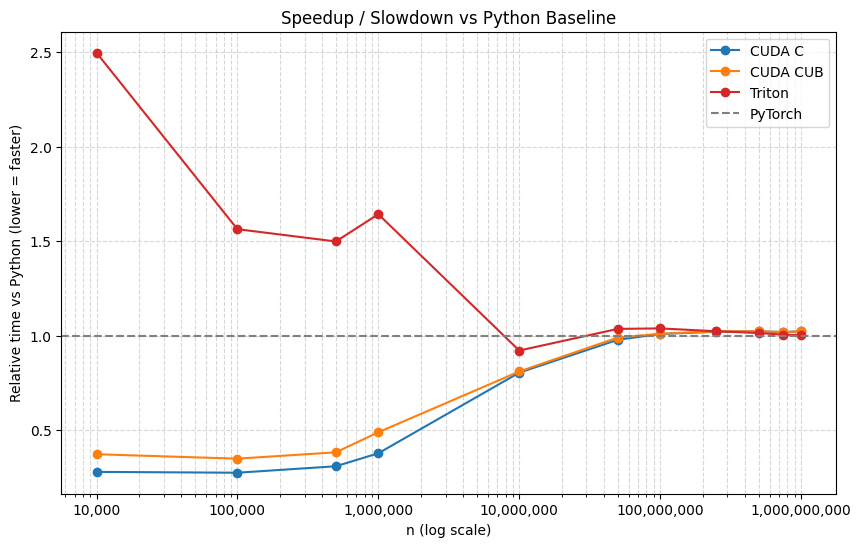

  Saved → analysis_output/3_speedup_vs_python.png


In [12]:
print("\n" + "═"*60)
print("4. Speedup Relative to Python Baseline")
print("═"*60)
baseline_name = "PyTorch"
if baseline_name in pivot.columns:
    speedup = pivot.div(pivot[baseline_name], axis=0)
    print(speedup.round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    for i, col in enumerate(speedup.columns):
        if col == baseline_name:
            continue
        ax.plot(speedup.index, speedup[col], marker="o", label=col, color=COLORS[i % len(COLORS)])
    ax.axhline(1.0, linestyle="--", color="gray", label=baseline_name)
    ax.set_xscale("log")
    ax.set_xlabel("n (log scale)")
    ax.set_ylabel("Relative time vs Python (lower = faster)")
    ax.set_title("Speedup / Slowdown vs Python Baseline")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    savefig("3_speedup_vs_python.png")
else:
    print(f"  [SKIP] Baseline '{baseline_name}' not found in data.")

In [13]:
print("\n" + "═"*60)
print("6. Fastest Script at Each n")
print("═"*60)
winner = pivot.idxmin(axis=1).reset_index()
winner.columns = ["n", "fastest_script"]
winner["fastest_ms"] = pivot.min(axis=1).values
winner["n"] = winner["n"].apply(lambda x: f"{int(x):,}")
print(winner.to_string(index=False))

print("\n✓ All analysis complete. Charts saved to:", OUT_DIR)


════════════════════════════════════════════════════════════
6. Fastest Script at Each n
════════════════════════════════════════════════════════════
            n fastest_script  fastest_ms
       10,000         CUDA C      0.0084
      100,000         CUDA C      0.0089
      500,000         CUDA C      0.0105
    1,000,000         CUDA C      0.0126
   10,000,000         CUDA C      0.1562
   50,000,000         CUDA C      0.7419
  100,000,000        PyTorch      1.4786
  250,000,000        PyTorch      3.6401
  500,000,000        PyTorch      7.2488
  750,000,000        PyTorch     10.9068
1,000,000,000        PyTorch     14.4752

✓ All analysis complete. Charts saved to: analysis_output


In [14]:
import csv, io, subprocess, sys
from pathlib import Path

# ======= configure these =======
INPUT_FILE = "out.bin"
N = 1_000_000_000
OUTPUT_CSV = "ncu_merged.csv"

NCU = "ncu"
CUDA_BIN = "./vector_sum_reduction"
CUB_BIN  = "./vector_sum_reduction_cub"
PYTHON   = "python3"
TRITON_SCRIPT = "vector_sum_reduction.py"
TORCH_SCRIPT = "vector_sum_reduction_torch.py" # New script to profile

APP_ARGS = ["--no-warmup", INPUT_FILE, str(N), "1"]  # no warmup, 1 timed iter

NCU_METRICS = (
    "gpu__time_duration.sum,"
    "dram__throughput.avg.pct_of_peak_sustained_elapsed,"
    "sm__warps_active.avg.pct_of_peak_sustained_active,"
    "smsp__thread_inst_executed_per_inst_executed.ratio,"
    "l1tex__throughput.avg.pct_of_peak_sustained_elapsed,"
    "l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,"
    "lts__t_sectors.avg.pct_of_peak_sustained_elapsed,"
    "l1tex__t_sector_hit_rate.pct,"
    "lts__t_sectors_srcunit_tex_op_read.sum,"
    "smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct,"
    "dram__bytes_read.sum,"
    "dram__bytes_write.sum"
)
# ===============================

def run(cmd, timeout_s=1800):
    return subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_s)

def profile_one(impl, run_cmd, kernel_regex=None, launch_count=None):
    # Nsight Compute appends ".ncu-rep" to whatever you pass to -o.
    # If you include the suffix in -o, you can end up with "*.ncu-rep.ncu-rep".
    rep_base = Path(f"report_{impl}")
    rep = rep_base.with_suffix(".ncu-rep")

    cmd = [
        NCU,
        "--target-processes", "application-only",
        "--metrics", NCU_METRICS,
        "-o", str(rep_base),
        "-f",  # overwrite existing report file
    ]
    if kernel_regex is not None:
        cmd += ["-k", f"regex:{kernel_regex}"]
    if launch_count is not None:
        cmd += ["-c", str(launch_count)]
    cmd += ["--"] + run_cmd

    print(f"[{impl}] {' '.join(cmd)}")
    r = run(cmd)

    if r.returncode != 0:
        print(f"[{impl}] ncu failed (returncode={r.returncode}). Full output below:", file=sys.stderr)
        if r.stdout:
            print("----- ncu stdout -----", file=sys.stderr)
            print(r.stdout, file=sys.stderr)
        if r.stderr:
            print("----- ncu stderr -----", file=sys.stderr)
            print(r.stderr, file=sys.stderr)
        return None

    if not rep.exists():
        print(f"[{impl}] Report file missing: {rep}", file=sys.stderr)
        return None

    return rep

def export_csv(rep):
    cmd = [NCU, "-i", str(rep), "--csv", "--page", "raw"]
    r = run(cmd, timeout_s=180)
    if r.returncode != 0:
        print(f"[export] failed for {rep}. Full output below:", file=sys.stderr)
        if r.stdout:
            print("----- export stdout -----", file=sys.stderr)
            print(r.stdout, file=sys.stderr)
        if r.stderr:
            print("----- export stderr -----", file=sys.stderr)
            print(r.stderr, file=sys.stderr)
        return None
    return r.stdout

def parse_raw_csv(csv_text, impl):
    rows = list(csv.reader(io.StringIO(csv_text)))
    if not rows:
        return None

    header = rows[0]
    data_start = 1

    # Skip "units" row commonly printed by ncu raw CSV
    if len(rows) > 1 and rows[1] and rows[1][0] == "" and (
        "byte" in str(rows[1]).lower() or "ns" in str(rows[1]).lower() or "%" in str(rows[1])
    ):
        data_start = 2

    if "implementation" not in header:
        header = ["implementation"] + header
    n_cols = len(header) - 1

    out_rows = []
    for r in rows[data_start:]:
        if not r or (len(r) == 1 and not r[0].strip()):
            continue
        r = (r + [""] * n_cols)[:n_cols]  # normalize row length
        out_rows.append([impl] + r)

    return header, out_rows

# Run all implementations
reports = []

# Gather all kernels for each implementation (no -k regex filtering)
reports.append(("cuda", profile_one(
    "cuda",
    [CUDA_BIN] + APP_ARGS,
    launch_count=2
)))

reports.append(("cub", profile_one(
    "cub",
    [CUB_BIN] + APP_ARGS
)))

reports.append(("triton", profile_one(
    "triton",
    [PYTHON, TRITON_SCRIPT] + APP_ARGS,
    launch_count=2
)))

reports.append(("torch_py", profile_one(
    "torch_py",
    [PYTHON, TORCH_SCRIPT] + APP_ARGS,
    launch_count=None
)))

reports = [(impl, rep) for impl, rep in reports if rep is not None]
if not reports:
    raise RuntimeError("No .ncu-rep reports produced")

# Export and merge
merged_header = None
merged_rows = []

for impl, rep in reports:
    txt = export_csv(rep)
    if not txt:
        continue
    parsed = parse_raw_csv(txt, impl)
    if not parsed:
        continue
    header, rows = parsed
    if merged_header is None:
        merged_header = header
    merged_rows.extend(rows)

if not merged_header or not merged_rows:
    raise RuntimeError("No CSV rows produced")

out_path = Path(OUTPUT_CSV)
with open(out_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(merged_header)
    w.writerows(merged_rows)

print(f"Done. Wrote merged CSV: {out_path.resolve()}")
print(f"Rows: {len(merged_rows)} (one per kernel launch)")

[cuda] ncu --target-processes application-only --metrics gpu__time_duration.sum,dram__throughput.avg.pct_of_peak_sustained_elapsed,sm__warps_active.avg.pct_of_peak_sustained_active,smsp__thread_inst_executed_per_inst_executed.ratio,l1tex__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,lts__t_sectors.avg.pct_of_peak_sustained_elapsed,l1tex__t_sector_hit_rate.pct,lts__t_sectors_srcunit_tex_op_read.sum,smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct,dram__bytes_read.sum,dram__bytes_write.sum -o report_cuda -f -c 2 -- ./vector_sum_reduction --no-warmup out.bin 1000000000 1
[cub] ncu --target-processes application-only --metrics gpu__time_duration.sum,dram__throughput.avg.pct_of_peak_sustained_elapsed,sm__warps_active.avg.pct_of_peak_sustained_active,smsp__thread_inst_executed_per_inst_executed.ratio,l1tex__throughput.avg.pct_of_peak_sustained_elapsed,l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld.sum,lts__t_sectors.

In [15]:
from pathlib import Path

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

# Config
csv_path = "ncu_merged.csv"
path = Path(csv_path)
if not path.is_file():
    raise FileNotFoundError(f"CSV not found: {path}")


def load_and_prepare(csv_path: str):
    df = pd.read_csv(csv_path)
    df = df[df["Kernel Name"].notna() & (df["Kernel Name"] != "")].copy()

    def to_num(s):
        return pd.to_numeric(
            s.astype(str)
            .str.replace(",", "", regex=False)
            .replace({"": None, "nan": None}),
            errors="coerce",
        )

    metric_cols = [
        "gpu__time_duration.sum",
        "dram__throughput.avg.pct_of_peak_sustained_elapsed",
        "sm__warps_active.avg.pct_of_peak_sustained_active",
        "smsp__thread_inst_executed_per_inst_executed.ratio",
        "l1tex__throughput.avg.pct_of_peak_sustained_elapsed",
        "lts__t_sectors.avg.pct_of_peak_sustained_elapsed",
        "smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct",
        "dram__bytes_read.sum",
        "dram__bytes_write.sum",
    ]
    for c in metric_cols:
        if c in df.columns:
            df[c] = to_num(df[c])

    launch_cols = [
        "launch__grid_dim_x",
        "launch__grid_size",
        "launch__block_dim_x",
        "launch__block_size",
    ]
    for c in launch_cols:
        if c in df.columns:
            df[c] = to_num(df[c])

    df["blocks"] = (
        df["launch__grid_dim_x"]
        if "launch__grid_dim_x" in df.columns
        else (
            df["launch__grid_size"]
            if "launch__grid_size" in df.columns
            else 0
        )
    )
    df["threads"] = (
        df["launch__block_size"]
        if "launch__block_size" in df.columns
        else (
            df["launch__block_dim_x"]
            if "launch__block_dim_x" in df.columns
            else 0
        )
    )
    df["ID"] = to_num(df["ID"])

    df["time_ms"] = df["gpu__time_duration.sum"] / 1e6
    df["warp_eff_pct"] = (
        df["smsp__thread_inst_executed_per_inst_executed.ratio"] * 100.0
    )
    df["dram_gb"] = (
        df["dram__bytes_read.sum"] + df["dram__bytes_write.sum"]
    ) / 1e9

    return df


def set_style():
    sns.set_theme(
        style="white",
        context="paper",
        font="serif",
        font_scale=1.15,
        rc={
            "figure.facecolor": "#fefefe",
            "axes.facecolor": "#fefefe",
            "axes.edgecolor": ".15",
            "axes.linewidth": 0.8,
            "axes.labelcolor": ".2",
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.color": ".3",
            "ytick.color": ".3",
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "grid.color": ".92",
            "grid.linewidth": 0.6,
            "grid.alpha": 1,
            "legend.frameon": True,
            "legend.framealpha": 0.95,
            "legend.edgecolor": ".9",
            "figure.dpi": 120,
            "savefig.dpi": 150,
            "savefig.bbox": "tight",
        },
    )


def barplot_pass1_pass2(df, metric: str, title: str, xlabel: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
    fig.patch.set_facecolor("#fefefe")

    for ax, id_val, sub_title in [
        (ax1, 0, "Reduction pass 1"),
        (ax2, 1, "Reduction pass 2"),
    ]:
        subset = df[df["ID"] == id_val].copy()
        if subset.empty:
            ax.set_title(sub_title, fontsize=10, fontweight="500", color=".25", pad=8)
            ax.set_yticks([])
            sns.despine(ax=ax, left=True, bottom=True)
            continue
        subset["implementation_pretty"] = subset["implementation"].map(NAME_MAP).fillna(subset["implementation"])
        order = None
        if metric == "time_ms":
            order = (
                subset.groupby("implementation_pretty")[metric]
                .mean()
                .sort_values(ascending=True)
                .index
            )
        sns.barplot(
            data=subset,
            x=metric,
            y="implementation_pretty",
            hue="implementation_pretty",
            ax=ax,
            palette=PALETTE,
            order=order,
            **BAR_KW,
        )
        ax.set_title(sub_title, fontsize=10, fontweight="500", color=".25", pad=8)
        ax.set_xlabel(xlabel, fontsize=10, color=".3")
        ax.set_ylabel("" if ax != ax1 else "Implementation", fontsize=10, color=".3")
        ax.tick_params(axis="both", which="major", length=3, color=".4")
        ax.xaxis.set_ticks_position("bottom")
        ax.yaxis.set_ticks_position("left")
        ax.set_axisbelow(True)
        ax.grid(axis="x", visible=True, color=".92", linewidth=0.6)
        ax.grid(axis="y", visible=False)
        sns.despine(ax=ax, left=(ax != ax1), bottom=False, top=True, right=True)

    fig.suptitle(title, fontsize=12, fontweight="600", color=".15", y=1.06)
    plt.tight_layout(rect=[0, 0, 1, 1.02])
    plt.show()


df = load_and_prepare(str(path))
set_style()

NAME_MAP = {
    "cuda": "CUDA C",
    "cub": "CUDA CUB",
    "triton": "Triton",
    "torch_py": "PyTorch",
}

PALETTE = {
    "CUDA C": "#4a7c8c",
    "CUDA CUB": "#c17b6a",
    "Triton": "#7d9e6b",
    "PyTorch": "#a87dc9",
}
BAR_KW = dict(
    orient="h",
    dodge=False,
    edgecolor="none",
    saturation=0.88,
    width=0.62,
    linewidth=0,
    legend=False,
)

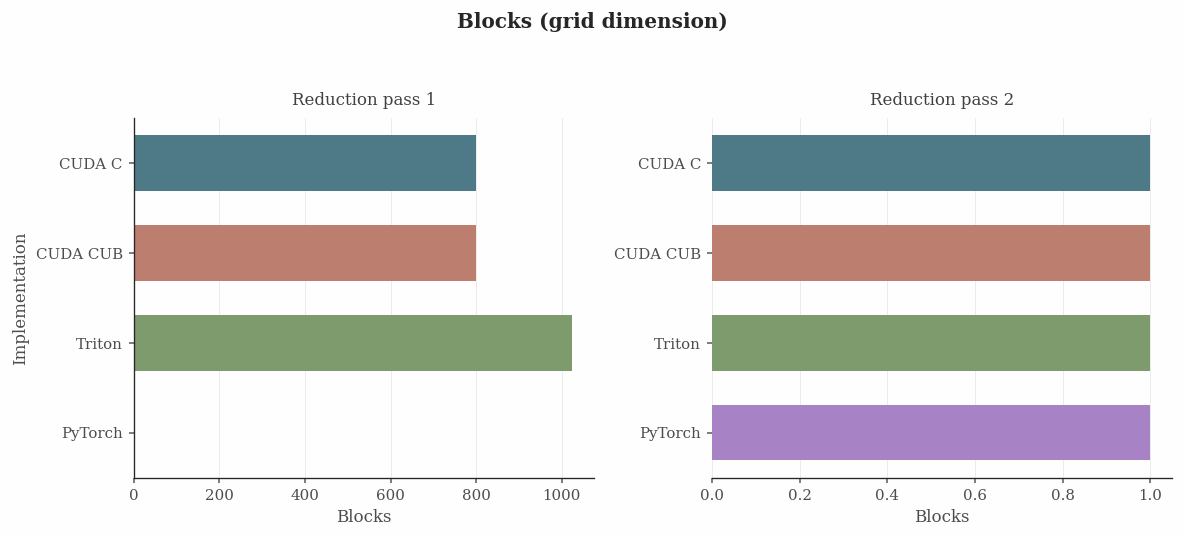

In [16]:
barplot_pass1_pass2(df, "blocks", "Blocks (grid dimension)", "Blocks")

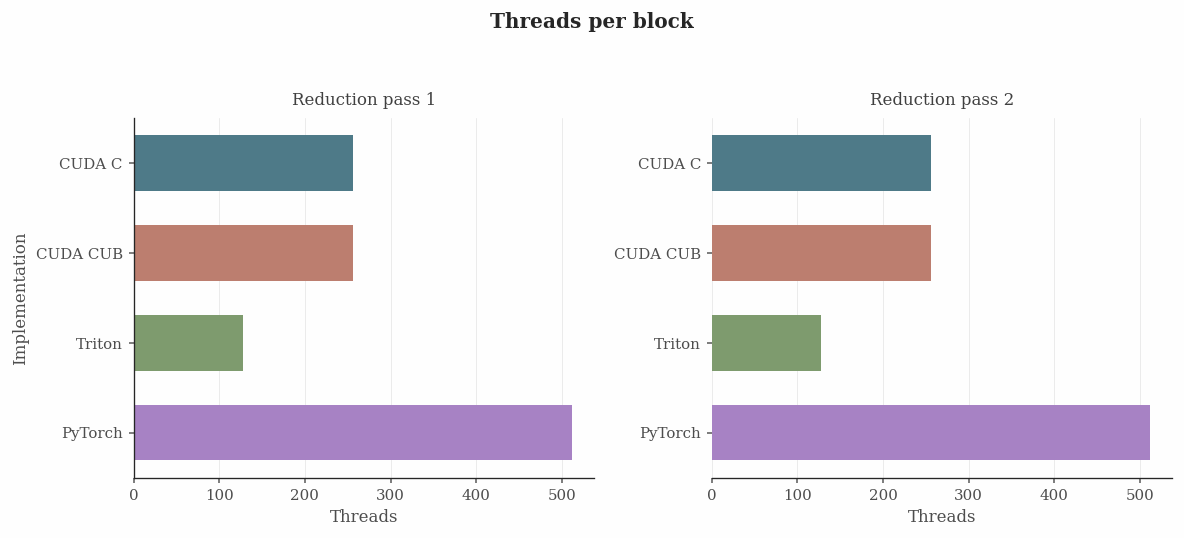

In [17]:
barplot_pass1_pass2(df, "threads", "Threads per block", "Threads")

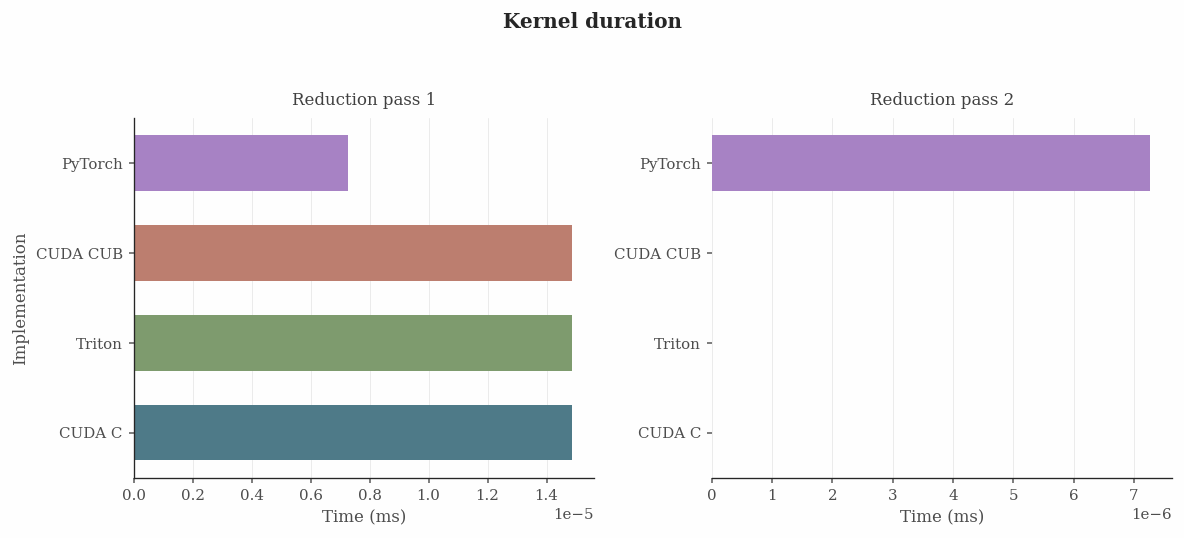

In [18]:
barplot_pass1_pass2(df, "time_ms", "Kernel duration", "Time (ms)")

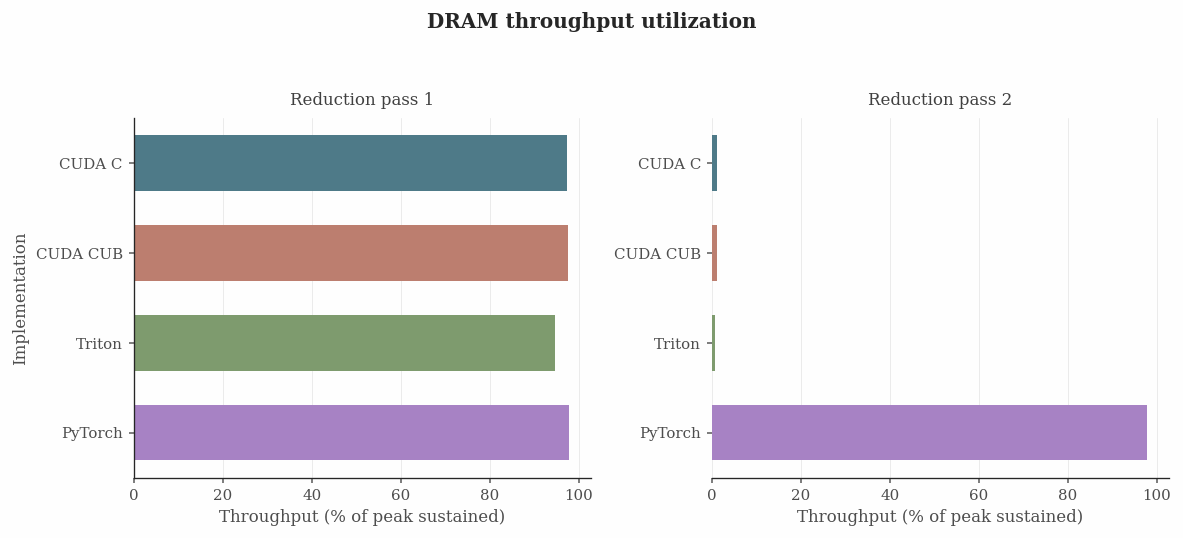

In [19]:
barplot_pass1_pass2(
    df,
    "dram__throughput.avg.pct_of_peak_sustained_elapsed",
    "DRAM throughput utilization",
    "Throughput (% of peak sustained)",
)

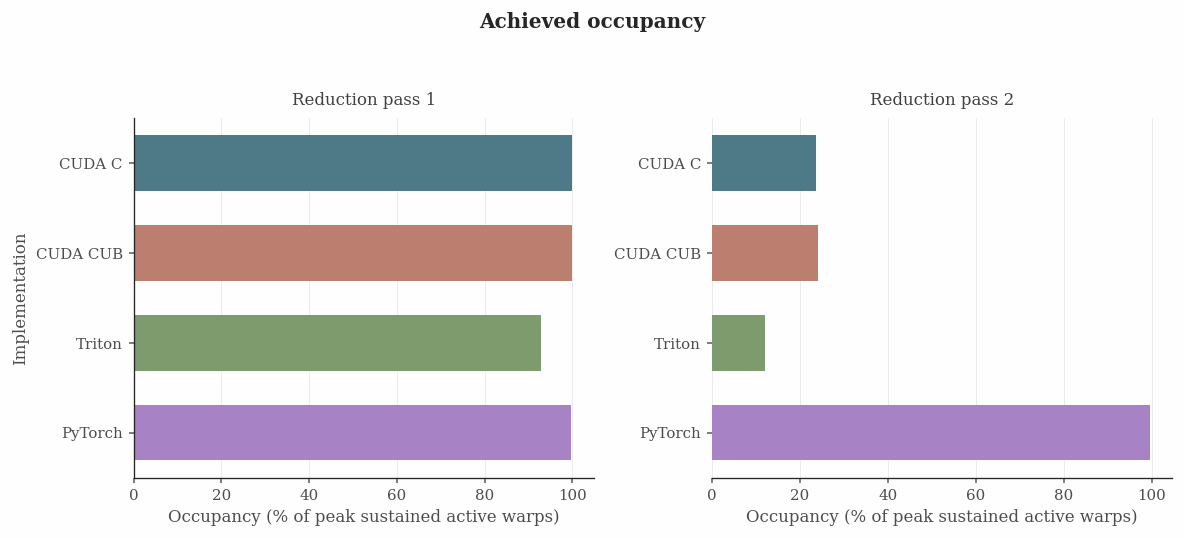

In [20]:
barplot_pass1_pass2(
    df,
    "sm__warps_active.avg.pct_of_peak_sustained_active",
    "Achieved occupancy",
    "Occupancy (% of peak sustained active warps)",
)

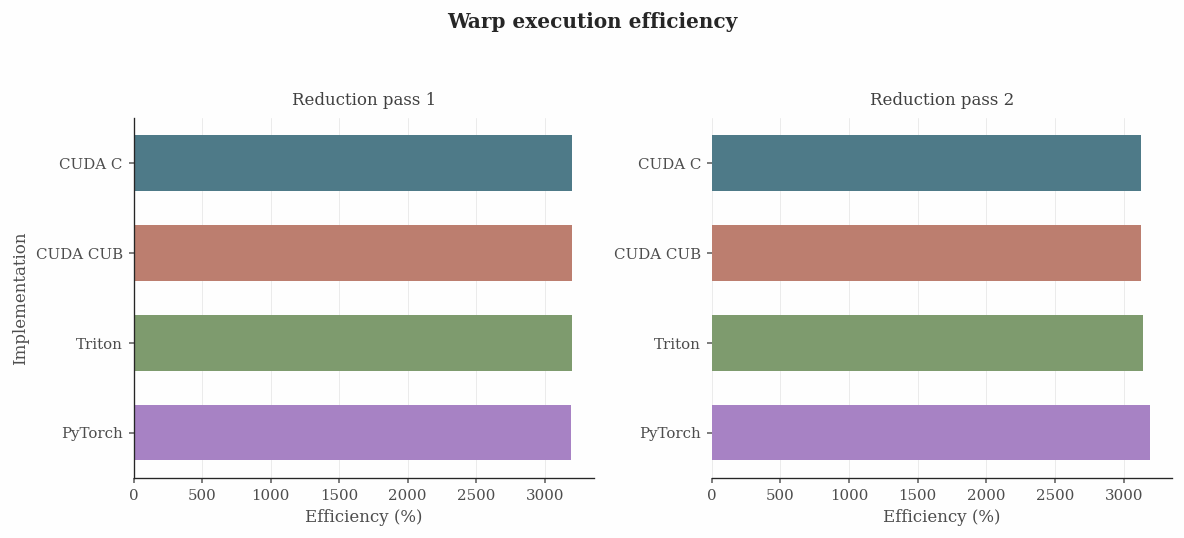

In [21]:
barplot_pass1_pass2(
    df,
    "warp_eff_pct",
    "Warp execution efficiency",
    "Efficiency (%)",
)

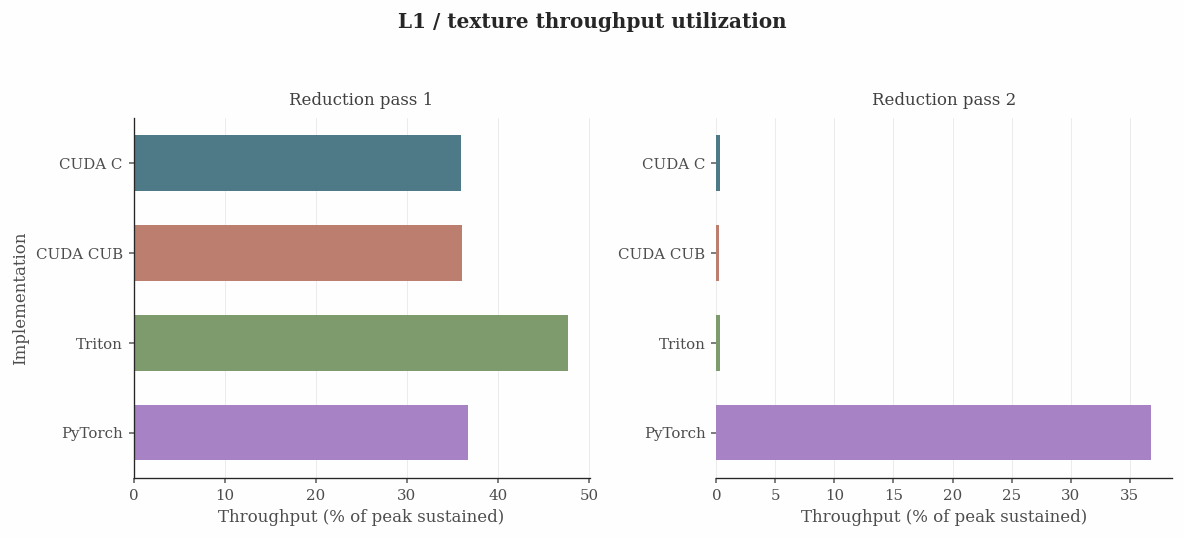

In [22]:
barplot_pass1_pass2(
    df,
    "l1tex__throughput.avg.pct_of_peak_sustained_elapsed",
    "L1 / texture throughput utilization",
    "Throughput (% of peak sustained)",
)

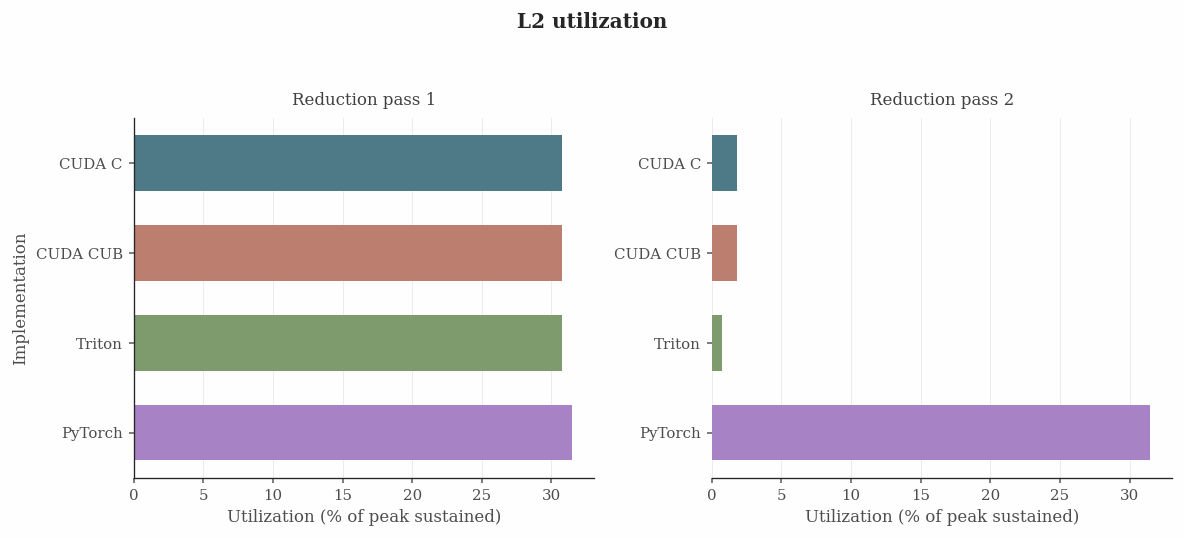

In [23]:
barplot_pass1_pass2(
    df,
    "lts__t_sectors.avg.pct_of_peak_sustained_elapsed",
    "L2 utilization",
    "Utilization (% of peak sustained)",
)

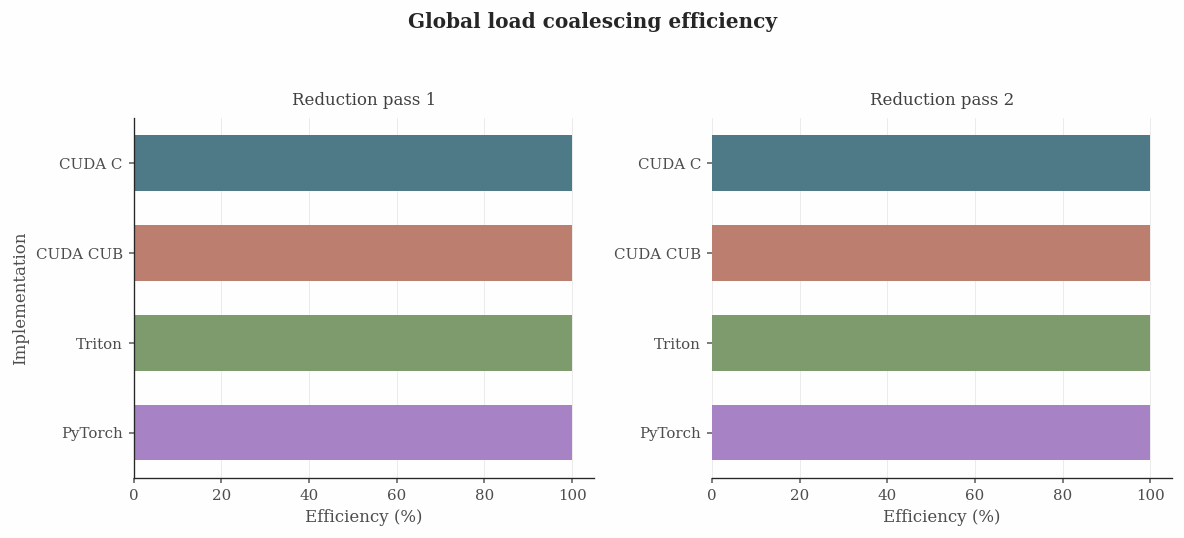

In [24]:
barplot_pass1_pass2(
    df,
    "smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct",
    "Global load coalescing efficiency",
    "Efficiency (%)",
)

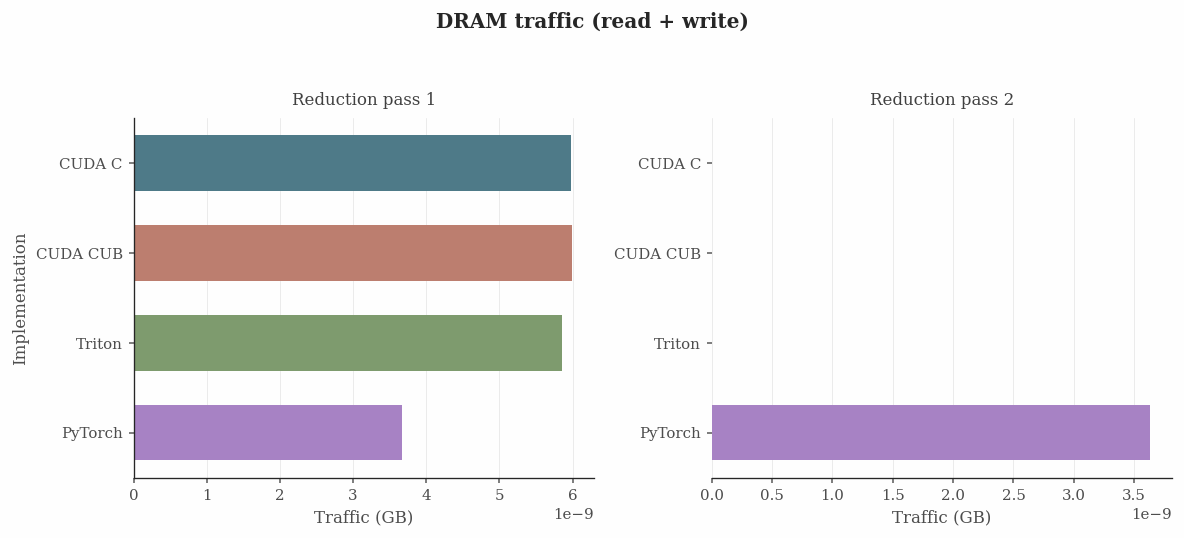

In [25]:
barplot_pass1_pass2(
    df, "dram_gb", "DRAM traffic (read + write)", "Traffic (GB)"
)

## CUDA C vs CUDA CUB
Plots comparing only the CUDA C (`cuda`) and CUDA CUB (`cub`) implementations for the same set of metrics shown above.

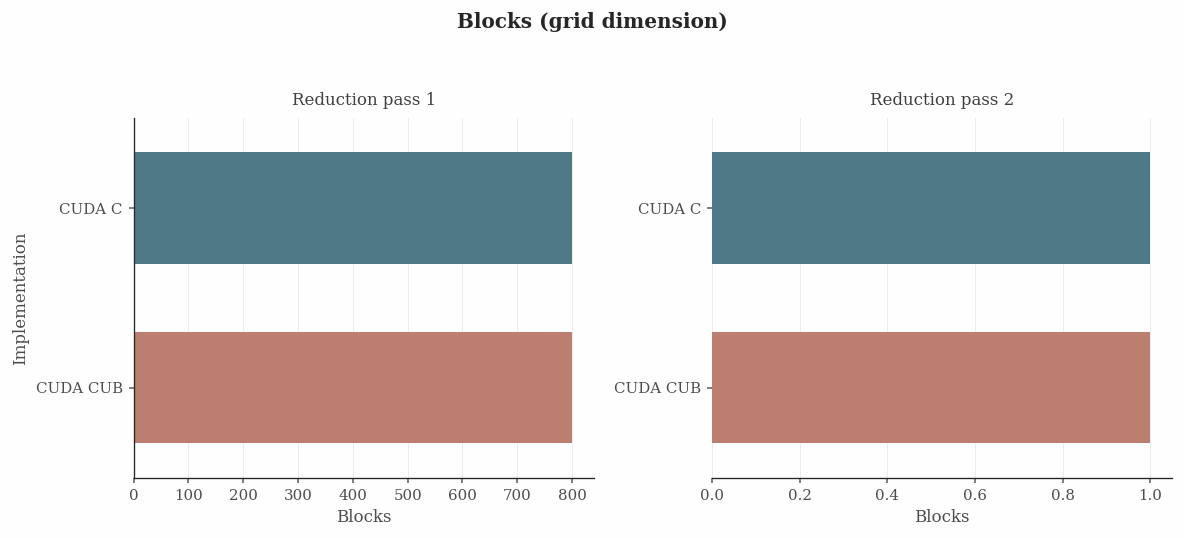

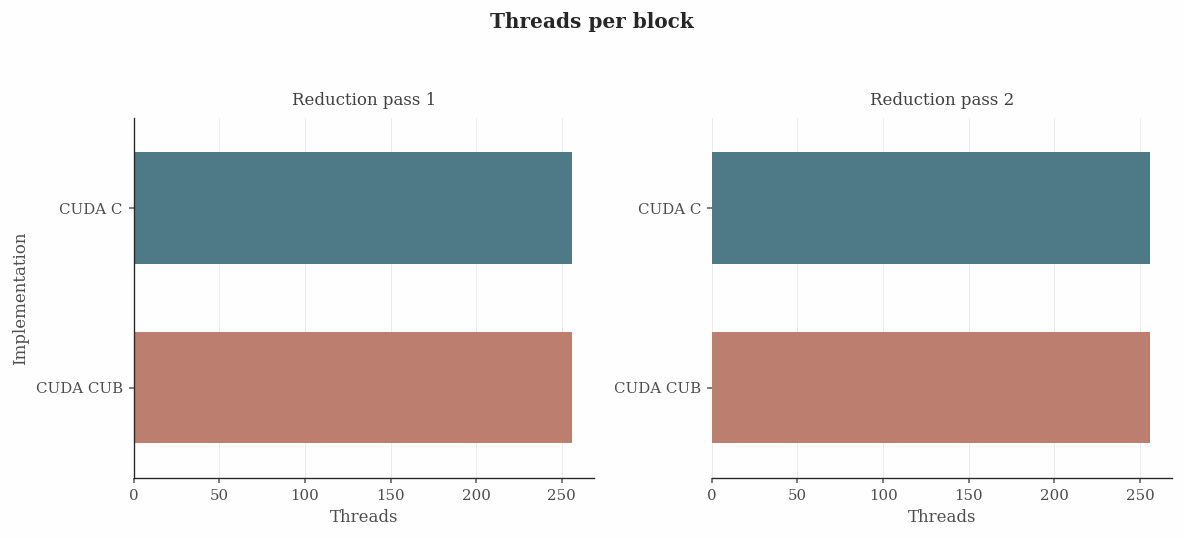

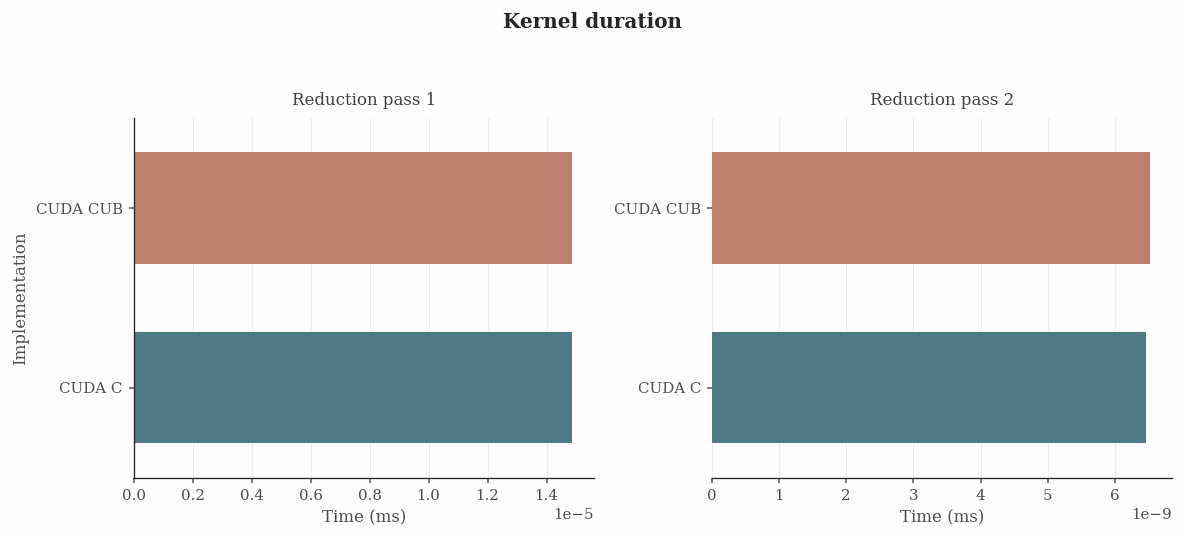

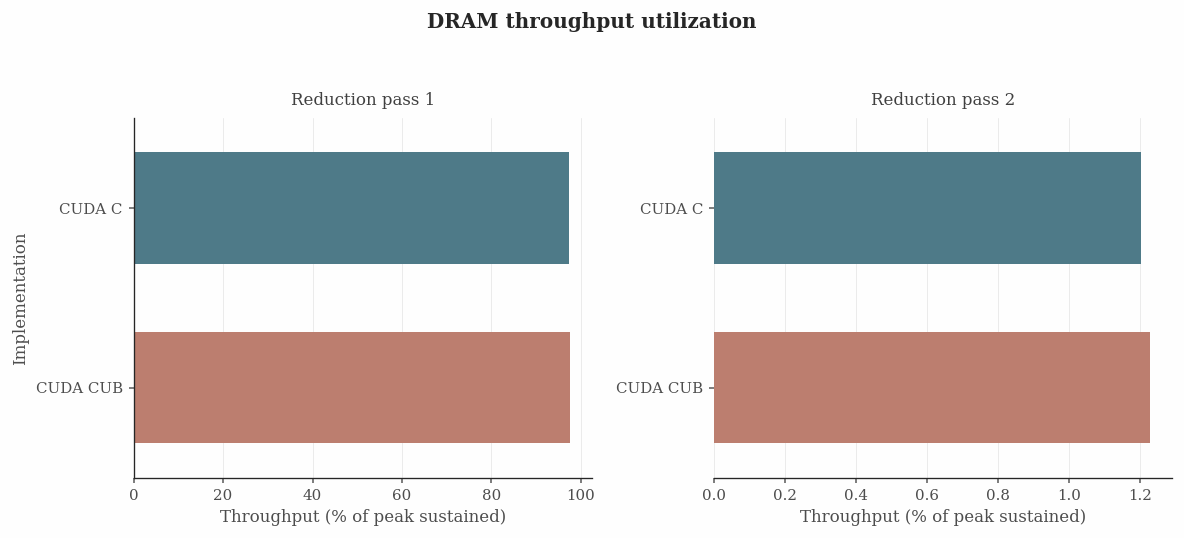

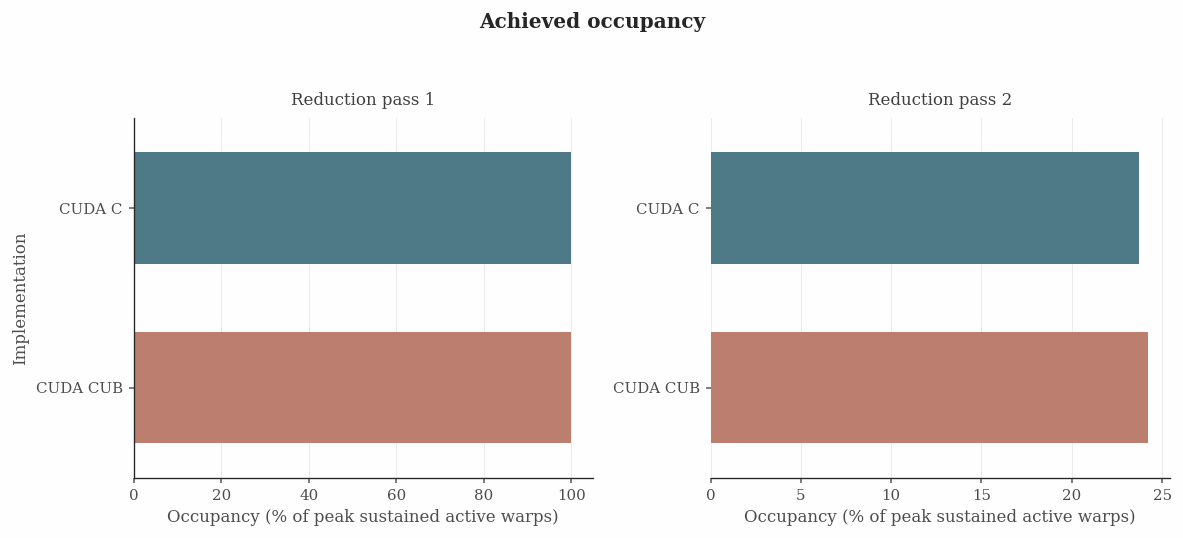

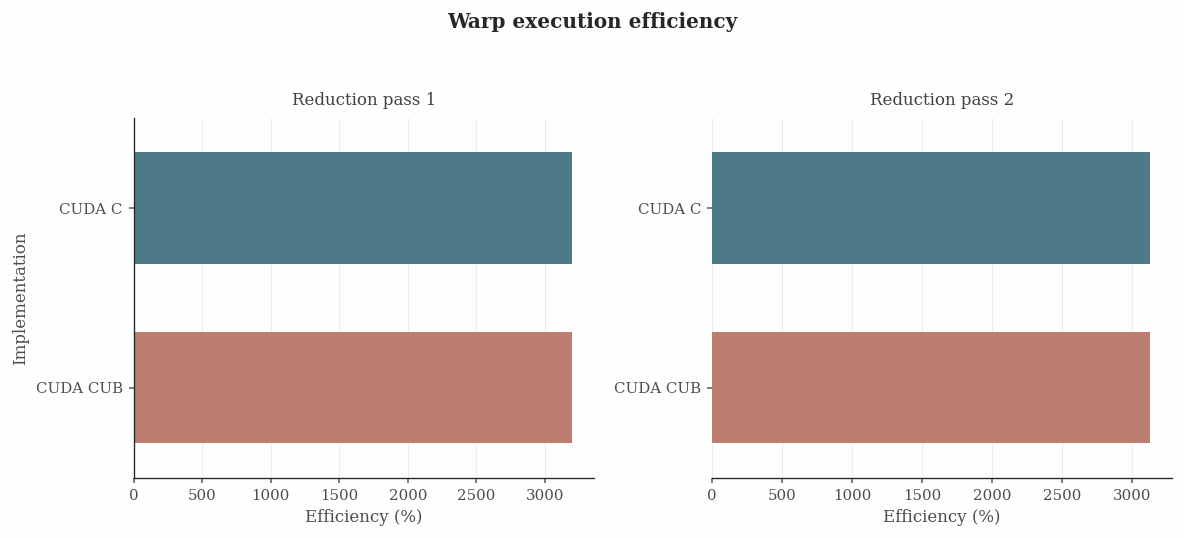

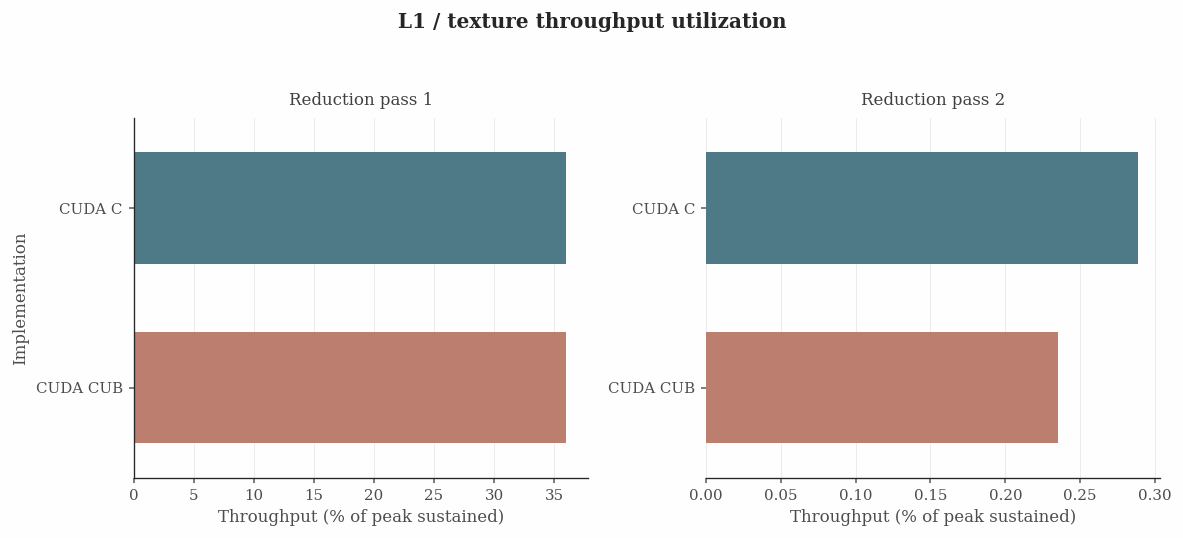

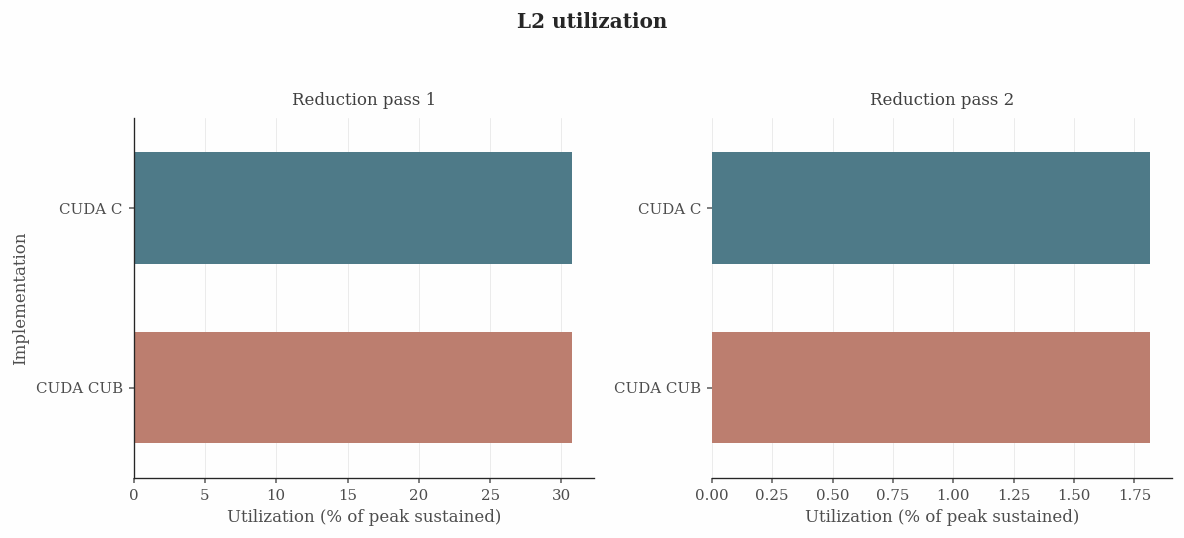

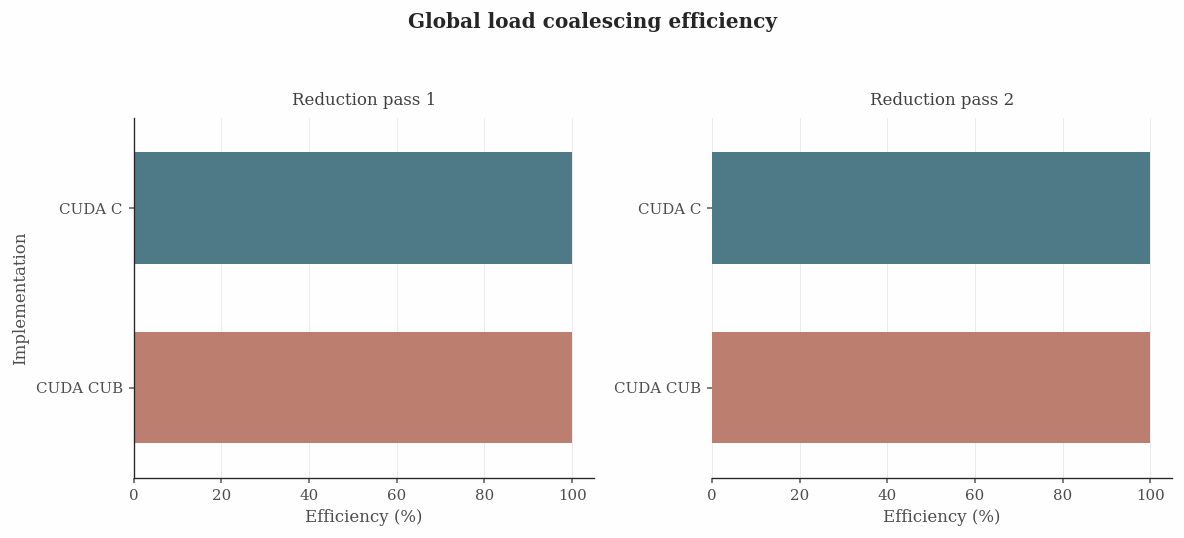

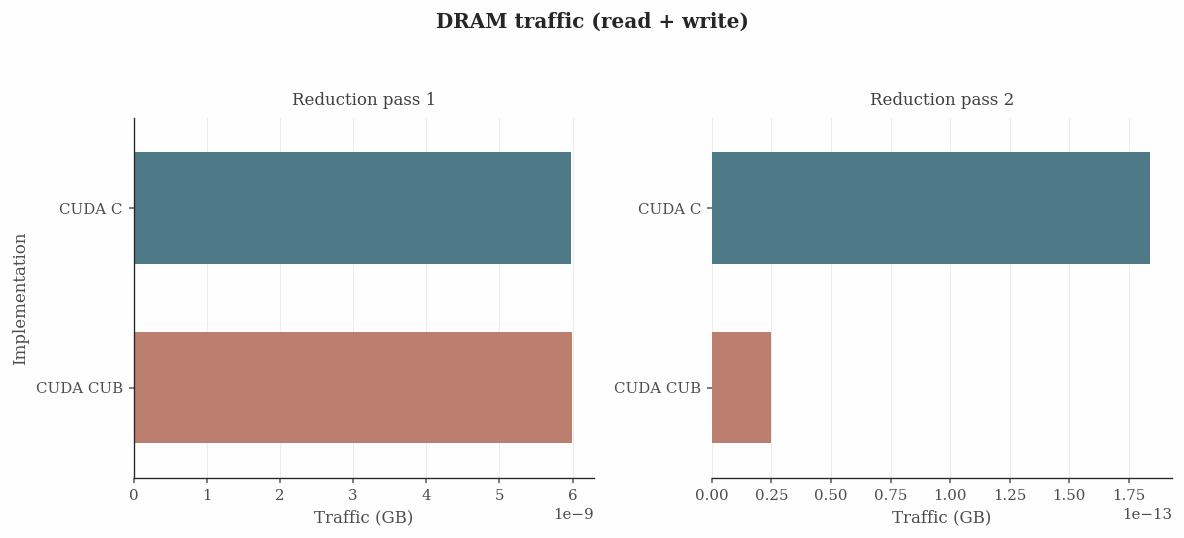

In [26]:
# Compare CUDA C vs CUDA CUB only

df_cuda_cub = df[df["implementation"].isin(["cuda", "cub"])].copy()

barplot_pass1_pass2(df_cuda_cub, "blocks", "Blocks (grid dimension)", "Blocks")
barplot_pass1_pass2(df_cuda_cub, "threads", "Threads per block", "Threads")
barplot_pass1_pass2(df_cuda_cub, "time_ms", "Kernel duration", "Time (ms)")

barplot_pass1_pass2(
    df_cuda_cub,
    "dram__throughput.avg.pct_of_peak_sustained_elapsed",
    "DRAM throughput utilization",
    "Throughput (% of peak sustained)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "sm__warps_active.avg.pct_of_peak_sustained_active",
    "Achieved occupancy",
    "Occupancy (% of peak sustained active warps)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "warp_eff_pct",
    "Warp execution efficiency",
    "Efficiency (%)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "l1tex__throughput.avg.pct_of_peak_sustained_elapsed",
    "L1 / texture throughput utilization",
    "Throughput (% of peak sustained)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "lts__t_sectors.avg.pct_of_peak_sustained_elapsed",
    "L2 utilization",
    "Utilization (% of peak sustained)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "smsp__sass_average_data_bytes_per_sector_mem_global_op_ld.pct",
    "Global load coalescing efficiency",
    "Efficiency (%)",
)

barplot_pass1_pass2(
    df_cuda_cub,
    "dram_gb",
    "DRAM traffic (read + write)",
    "Traffic (GB)",
)
